# S2 | Model: Confidence & Calibration

**Session 2** — 1k VQA control question pool.

Analyses model confidence (logprob-based) across conditions (`original`, `blind`, `inst_blind`) and control variant types.


In [ ]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

RESULTS_DIR = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']

COMPLETE_MODELS = [
    'llava-v1.6-vicuna-7b-hf',
    'llava-v1.6-vicuna-13b-hf',
    'Qwen3-VL-2B-Instruct',
    'Qwen3-VL-4B-Instruct',
]

mapper = VQAAnswerMapper()
sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op']]

def load_confidence(model, dataset):
    path = f'{RESULTS_DIR}/{model}/{dataset}.jsonl'
    if not os.path.exists(path):
        return []
    rows = []
    with open(path) as f:
        data_list = [json.loads(l) for l in f]
    n = len(data_list)
    if n == 0:
        return []
    status = 'OK' if n == 1000 else f'WARNING: {n}/1000'
    print(f'  [{status}] {model} | {dataset}')

    for ex in data_list:
        if 'generated_logits' not in ex:
            continue
        answers = ex.get('generated_answers') or {}
        gt = mapper.get_answers(ex['question_id'])
        for ct, logit_data in ex['generated_logits'].items():
            if ct not in CONTROL_TYPES:
                continue
            output = answers.get(ct, '')
            if output == '':
                continue
            token_probs = np.exp([t['logprob'] for t in logit_data['content']])
            rows.append({
                'model': model,
                'dataset': dataset,
                'question_id': ex['question_id'],
                'question_text': ex.get(ct, ''),
                'control_type': ct,
                'output': output,
                'confidence': float(token_probs.mean()),
                'accuracy': vqa_accuracy(output, gt) if gt else None,
            })
    return rows

# All three conditions: control (with image), blind (no image), inst_blind (no image + instruction)
datasets = ['vqa_1k_control', 'vqa_1k_control_blind', 'vqa_1k_control_inst_blind']
all_rows = []
for model in COMPLETE_MODELS:
    for ds in datasets:
        all_rows.extend(load_confidence(model, ds))

df = pd.DataFrame(all_rows)
df['accuracy'] = pd.to_numeric(df['accuracy'], errors='coerce')
df['control_type'] = pd.Categorical(df['control_type'], categories=CONTROL_TYPES, ordered=True)
df = df.merge(sem_df, on='question_id', how='left')

print(f'\nLoaded {len(df):,} rows | {df["model"].nunique()} models | {df["question_id"].nunique()} questions')
print(f'Datasets: {df["dataset"].unique().tolist()}')
print(f'Control types present: {sorted(df["control_type"].dropna().unique())}')

In [2]:
# Sanity-check: pivot a few questions to compare control types side by side
df[['model', 'question_id', 'control_type', 'dataset', 'output', 'confidence', 'accuracy']]\
    .pivot_table(
        index=['question_id', 'control_type'],
        columns=['dataset'],
        values=['output', 'confidence'],
        aggfunc=lambda x: ' | '.join(x.astype(str))
    ).reindex(CONTROL_TYPES, level='control_type').dropna(axis=0).head(20)

confidence  \
dataset                                                         vqa_1k_control   
question_id control_type                                                         
589013      question         0.8266035858047291 | 0.8639899511733848 | 0.99...   
            deictic_removed  0.8266035858047291 | 0.8639899511733848 | 0.99...   
            object_removed   0.8266035858047291 | 0.8639899511733848 | 0.99...   
            weaker_object    0.8266035858047291 | 0.8639899511733848 | 0.99...   
            pronominalized   0.8266035858047291 | 0.9787001740280632 | 0.99...   
757004      question         0.8111396759313092 | 0.7790435272673468 | 0.98...   
            deictic_removed  0.7962360650387396 | 0.7905193895630517 | 0.97...   
            object_removed   0.8165766962048836 | 0.8147381786294834 | 0.89...   
            weaker_object    0.7829142528954549 | 0.782855433567096 | 0.933...   
            pronominalized   0.8237992092516777 | 0.8721193385769237 | 0.91...   
1342072     question         0.5648321404039972 | 0.6408221039002799 | 0.94...   
            deictic_removed  0.5648321404039972 | 0.6408221039002799 | 0.94...   
            object_removed   0.5395322246029775 | 0.5953619330384412 | 0.87...   
            weaker_object    0.546300285554474 | 0.588489688285578 | 0.9241...   
            pronominalized   0.5763913742997047 | 0.5036916764053972 | 0.85...   
2006001     question         0.918366896180033 | 0.8608671559019703 | 0.742...   
            deictic_removed  0.918366896180033 | 0.8608671559019703 | 0.742...   
            object_removed   0.8713711913183547 | 0.8489140314288228 | 0.89...   
            weaker_object    0.9130442650863603 | 0.8759138331807469 | 0.74...   
            pronominalized   0.9007882160279248 | 0.7685160612516628 | 0.98...   

                                                                                \
dataset                                              vqa_1k_control_inst_blind   
question_id control_type                                                         
589013      question         0.9352252993275836 | 0.8640560526743368 | 0.73...   
            deictic_removed  0.9352252993275836 | 0.8640560526743368 | 0.73...   
            object_removed   0.9352252993275836 | 0.8640560526743368 | 0.73...   
            weaker_object    0.9352252993275836 | 0.8640560526743368 | 0.73...   
            pronominalized   0.9352252993275836 | 0.7309871307489731 | 0.70...   
757004      question         0.9165179445952696 | 0.8322466828257098 | 0.98...   
            deictic_removed  0.9131099064925382 | 0.9082851727767457 | 0.92...   
            object_removed   0.8237585845076375 | 0.8305532393864301 | 0.81...   
            weaker_object    0.9001484780315971 | 0.8524312062136749 | 0.73...   
            pronominalized   0.8164867590339606 | 0.9460677127415138 | 0.74...   
1342072     question         0.6779211393660054 | 0.5542787094238947 | 0.65...   
            deictic_removed  0.6779211393660054 | 0.5542787094238947 | 0.65...   
            object_removed   0.6470956495241152 | 0.5628266789901297 | 0.61...   
            weaker_object    0.515431418530315 | 0.7700635805147107 | 0.676...   
            pronominalized   0.5677805079456985 | 0.5724639254039553 | 0.84...   
2006001     question         0.6985351038820639 | 0.816415850246403 | 0.502...   
            deictic_removed  0.6985351038820639 | 0.816415850246403 | 0.502...   
            object_removed   0.6645059039163891 | 0.8492494192362763 | 0.67...   
            weaker_object    0.7604925357559946 | 0.875506523734729 | 0.702...   
            pronominalized   0.7786562155148388 | 0.6909668163426472 | 0.84...   

                                                           output  \
dataset                                            vqa_1k_control   
question_id control_type                                            
589013      question                        Night | Night | night   
            deicti

In [3]:
# Data already scored and merged in setup cell — quick sanity check
print(f"Rows: {len(df):,}  |  Models: {df['model'].nunique()}  |  Questions: {df['question_id'].nunique()}")
print(f"Control types: {list(df['control_type'].cat.categories)}")
df[['model', 'dataset', 'control_type', 'output', 'confidence', 'accuracy', 'ent']].head(10)

Rows: 37,928  |  Models: 4  |  Questions: 1000
Control types: ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']


,model,dataset,control_type,output,confidence,accuracy,ent
0,llava-v1.6-vicuna-7b-hf,vqa_1k_control,question,1,0.974205,1.0,object
1,llava-v1.6-vicuna-7b-hf,vqa_1k_control,deictic_removed,1,0.974560,1.0,object
2,llava-v1.6-vicuna-7b-hf,vqa_1k_control,object_removed,1,0.846013,1.0,object
3,llava-v1.6-vicuna-7b-hf,vqa_1k_control,weaker_object,1,0.900691,1.0,object
4,llava-v1.6-vicuna-7b-hf,vqa_1k_control,pronominalized,1,0.753529,1.0,object
5,llava-v1.6-vicuna-7b-hf,vqa_1k_control,question,On building,0.656381,1.0,object
6,llava-v1.6-vicuna-7b-hf,vqa_1k_control,deictic_removed,On building,0.656381,1.0,object
7,llava-v1.6-vicuna-7b-hf,vqa_1k_control,object_removed,Street,0.645027,0.0,object
8,llava-v1.6-vicuna-7b-hf,vqa_1k_control,weaker_object,Wall,0.739510,0.0,object
9,llava-v1.6-vicuna-7b-hf,vqa_1k_control,pronominalized,Street,0.688975,0.0,object


In [4]:
control_type_order = CONTROL_TYPES

summary = (
    df.groupby(['model', 'dataset', 'control_type'])
    .agg(accuracy=('accuracy', 'mean'), confidence=('confidence', 'mean'), n=('accuracy', 'count'))
    .reset_index()
)
summary['accuracy'] = (summary['accuracy'] * 100).round(1)
summary['confidence'] = (summary['confidence'] * 100).round(1)
summary['control_type'] = pd.Categorical(summary['control_type'], categories=control_type_order, ordered=True)
summary = summary.sort_values(['model', 'dataset', 'control_type'])

summary.pivot_table(
    index=['model', 'control_type'],
    columns='dataset',
    values=['accuracy', 'confidence'],
).round(1)

accuracy  \
dataset                                  vqa_1k_control   
model                    control_type                     
Qwen3-VL-2B-Instruct     question                  80.6   
                         deictic_removed           80.5   
                         object_removed            69.1   
                         weaker_object             74.7   
                         pronominalized            67.0   
Qwen3-VL-4B-Instruct     question                  81.4   
                         deictic_removed           81.0   
                         object_removed            72.0   
                         weaker_object             75.2   
                         pronominalized            69.8   
llava-v1.6-vicuna-13b-hf question                  82.9   
                         deictic_removed           82.4   
                         object_removed            71.6   
                         weaker_object             76.0   
llava-v1.6-vicuna-7b-hf  question                  82.6   
                         deictic_removed           82.4   
                         object_removed            72.2   
                         weaker_object             76.0   
                         pronominalized            69.4   

                                                                    \
dataset                                  vqa_1k_control_inst_blind   
model                    control_type                                
Qwen3-VL-2B-Instruct     question                             35.6   
                         deictic_removed                      35.2   
                         object_removed                       32.5   
                         weaker_object                        33.2   
                         pronominalized                       31.1   
Qwen3-VL-4B-Instruct     question                             37.1   
                         deictic_removed                      37.1   
                         object_removed                       31.8   
                         weaker_object                        32.8   
                         pronominalized                       30.8   
llava-v1.6-vicuna-13b-hf question                             36.2   
                         deictic_removed                      36.2   
                         object_removed                       34.2   
                         weaker_object                        33.4   
llava-v1.6-vicuna-7b-hf  question                             34.7   
                         deictic_removed                      34.7   
                         object_removed                       33.6   
                         weaker_object                        33.0   
                         pronominalized                       32.2   

                                             confidence  \
dataset                                  vqa_1k_control   
model                    control_type                     
Qwen3-VL-2B-Instruct     question                  89.2   
                         deictic_removed           89.1   
                         object_removed            88.1   
                         weaker_object             88.7   
                         pronominalized            86.8   
Qwen3-VL-4B-Instruct     question                  93.7   
                         deictic_removed           93.6   
                         object_removed            92.8   
                         weaker_object             93.6   
                         pronominalized            92.9   
llava-v1.6-vicuna-13b-hf question                  87.5   
                         deictic_removed           87.4   
                         object_removed            84.7   
                         weaker_object             86.5   
llava-v1.6-vicuna-7b-hf  question                  87.4   
                         deictic_removed           87.3   
                         object_removed            85.0   
                         we

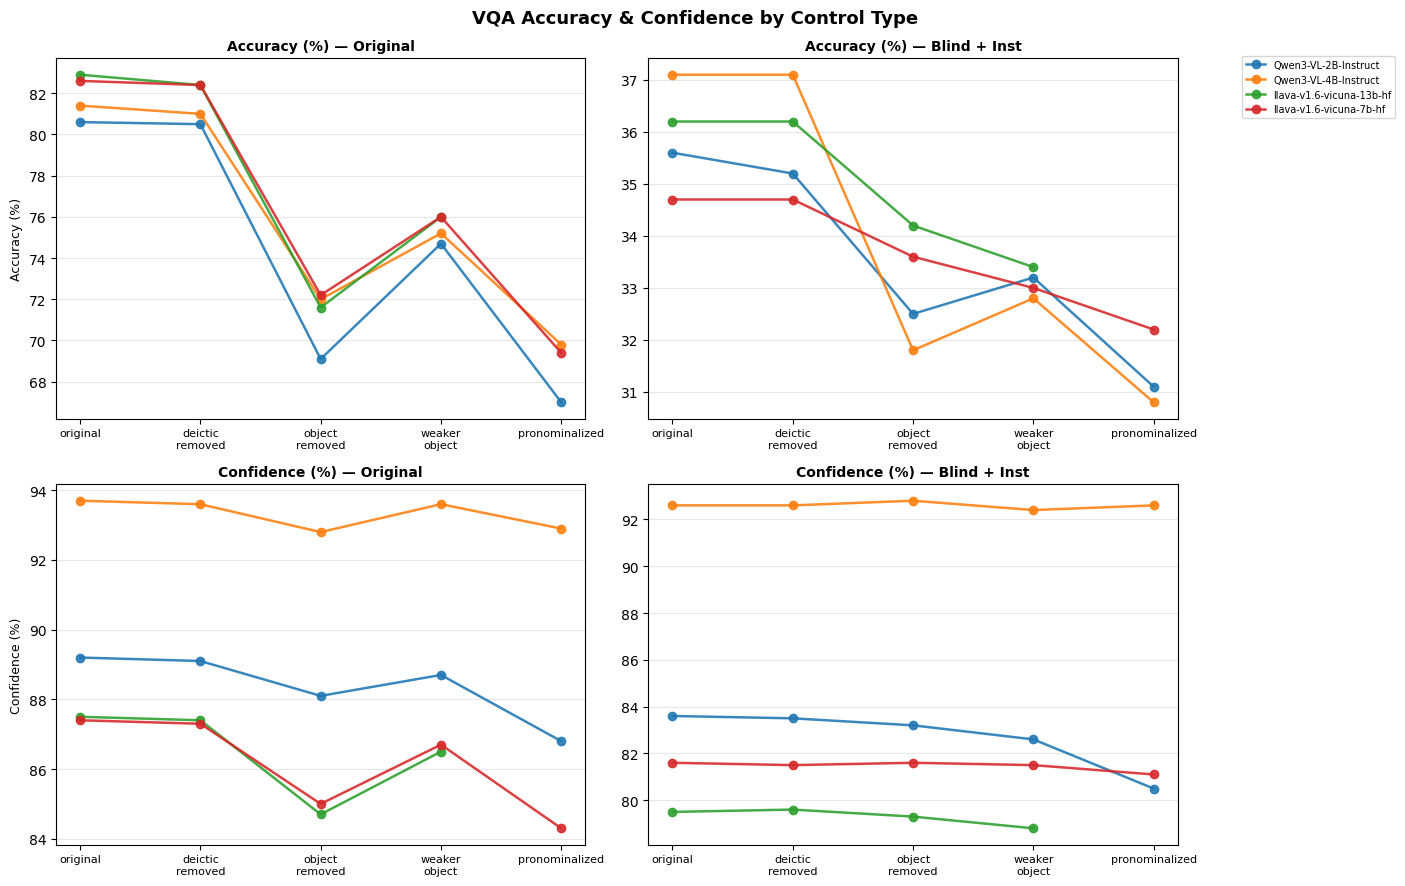

In [5]:
import matplotlib.pyplot as plt

datasets = ['vqa_1k_control', 'vqa_1k_control_inst_blind']
ds_labels = {'vqa_1k_control': 'Original', 'vqa_1k_control_inst_blind': 'Blind + Inst'}
ct_labels = ['original', 'deictic\nremoved', 'object\nremoved', 'weaker\nobject', 'pronominalized']
models_list = sorted(summary['model'].unique())
model_colors = {m: plt.cm.tab10(i) for i, m in enumerate(models_list)}
x = range(len(control_type_order))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row_i, metric in enumerate(['accuracy', 'confidence']):
    ylabel = 'Accuracy (%)' if metric == 'accuracy' else 'Confidence (%)'
    for col_i, ds in enumerate(datasets):
        ax = axes[row_i][col_i]
        for model in models_list:
            sub = summary[(summary['model'] == model) & (summary['dataset'] == ds)]
            if sub.empty or sub[metric].isna().all():
                continue
            sub = sub.set_index('control_type').reindex(control_type_order)
            ax.plot(x, sub[metric].values,
                    color=model_colors[model], marker='o', linewidth=1.8,
                    label=model, alpha=0.88)
        ax.set_xticks(list(x))
        ax.set_xticklabels(ct_labels, fontsize=8)
        ax.set_title(f'{ylabel} — {ds_labels[ds]}', fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row_i == 0 and col_i == 1:
            ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.42, 1.02))

plt.suptitle('VQA Accuracy & Confidence by Control Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

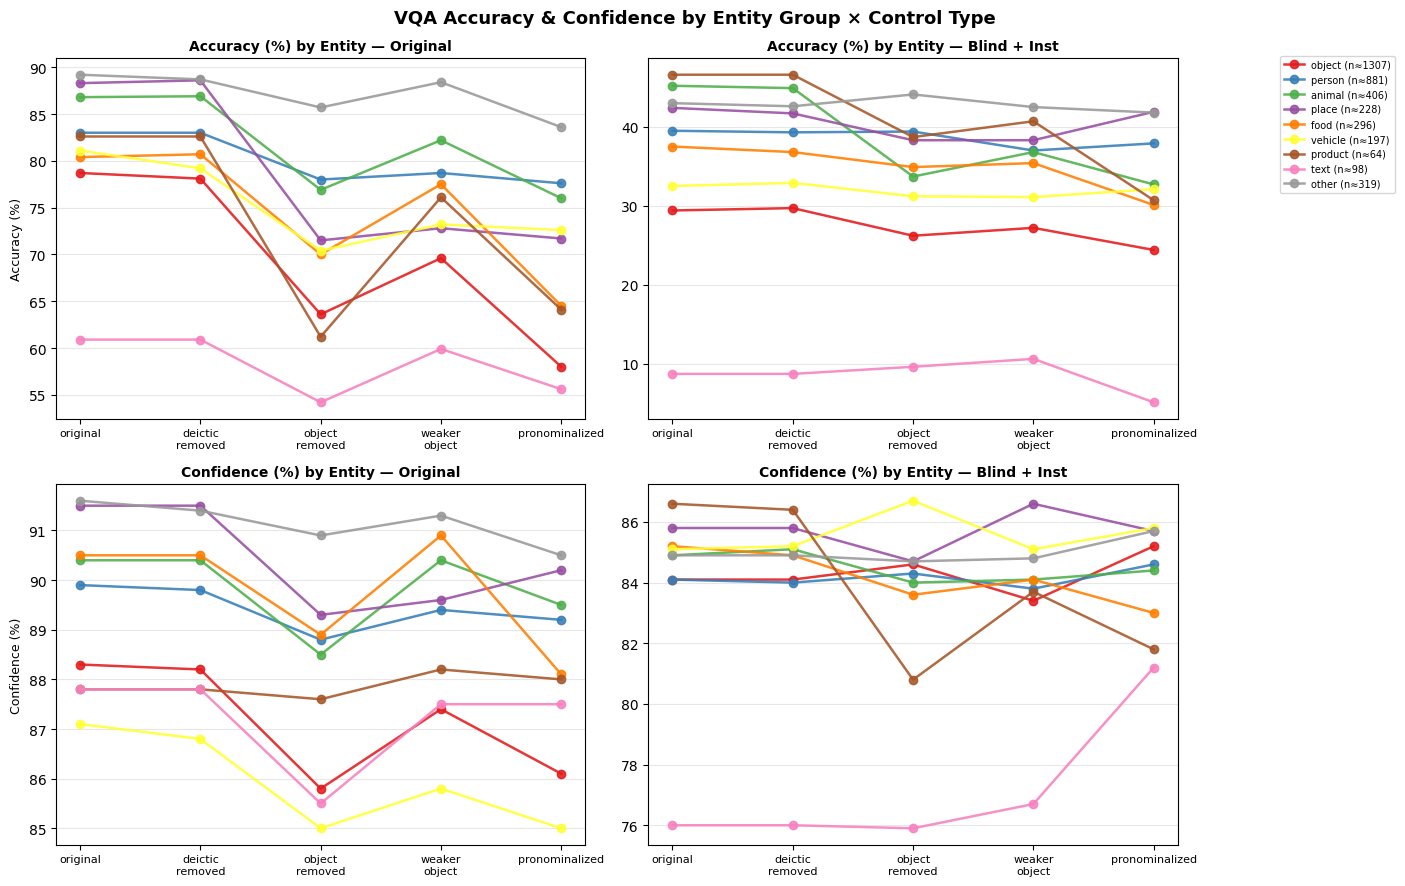

In [6]:
# Entity group analysis: accuracy and confidence across control types
ENT_ORDER = ['object', 'person', 'animal', 'place', 'food', 'vehicle', 'product', 'text', 'other']

ent_summary = (
    df[df['ent'].notna()]
    .groupby(['ent', 'dataset', 'control_type'])
    .agg(accuracy=('accuracy', 'mean'), confidence=('confidence', 'mean'), n=('accuracy', 'count'))
    .reset_index()
)
ent_summary['accuracy'] = (ent_summary['accuracy'] * 100).round(1)
ent_summary['confidence'] = (ent_summary['confidence'] * 100).round(1)
ent_summary['control_type'] = pd.Categorical(
    ent_summary['control_type'], categories=control_type_order, ordered=True
)

ent_colors = {e: plt.cm.Set1(i / len(ENT_ORDER)) for i, e in enumerate(ENT_ORDER)}

fig, axes = plt.subplots(2, 2, figsize=(14, 9)) # , sharey='row')

for row_i, metric in enumerate(['accuracy', 'confidence']):
    ylabel = 'Accuracy (%)' if metric == 'accuracy' else 'Confidence (%)'
    for col_i, ds in enumerate(datasets):
        ax = axes[row_i][col_i]
        for ent in ENT_ORDER:
            sub = ent_summary[(ent_summary['ent'] == ent) & (ent_summary['dataset'] == ds)]
            if sub.empty or sub[metric].isna().all():
                continue
            sub = sub.set_index('control_type').reindex(control_type_order)
            n_mean = int(ent_summary[(ent_summary['ent'] == ent) & (ent_summary['dataset'] == ds)]['n'].mean())
            ax.plot(x, sub[metric].values,
                    color=ent_colors[ent], marker='o', linewidth=1.8,
                    label=f'{ent} (n≈{n_mean})', alpha=0.88)
        ax.set_xticks(list(x))
        ax.set_xticklabels(ct_labels, fontsize=8)
        ax.set_title(f'{ylabel} by Entity — {ds_labels[ds]}', fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row_i == 0 and col_i == 1:
            ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.42, 1.02))

plt.suptitle('VQA Accuracy & Confidence by Entity Group × Control Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
